## SU Decomposition Example

### Introduction
This notebook contains some numerical examples of the *Dual-Upper-Triangular Invariant Representation (DUTIR)* of rigid body motion trajectory data.

In this notebook, the available trajectory data types are:
1. synthetic data of a helical translation, a rotation about a fixed axis, and a precession motion;
2. real data from a recording of a human-demonstrated pouring motion. 

The computation of the DUTIR is based on the *SU-decomposition* algorithm.
You can change the value for the regularization parameter *L* used within the SU-decomposition algorithm. Based on your specified value for *L*, the notebook provides a comparison of the unregularized results versus the regularized result.

### Running the code

##### 1. Import python libraries and add the data folder to the python path

In [1]:
import pathlib
import sys

parent_folder = str(pathlib.Path().cwd().parent)
sys.path.append(parent_folder)

path_to_data = rf"{parent_folder}/data"
path_to_figures = rf"{parent_folder}/figures"

##### 2. Specify the type of input trajectory (*'pouring', 'helical_translation', 'axis_rotation', and 'precession' are supported*)

In [2]:
input_trajectory = "pouring"

##### 3. Load and preprocess the trajectory data

In [3]:
import sulib._data_handling as _dh
import sulib._preprocessing as _pp

# Load the trajectory data
T, N, dt = _dh.load_demo_trajectory_motion(input_trajectory, path_to_data)
total_time = (N - 1) * dt

# Filter the trajectory data
T = _pp.filter_pose_data(T, sigma=3)

##### 4. Plot the trajectory data

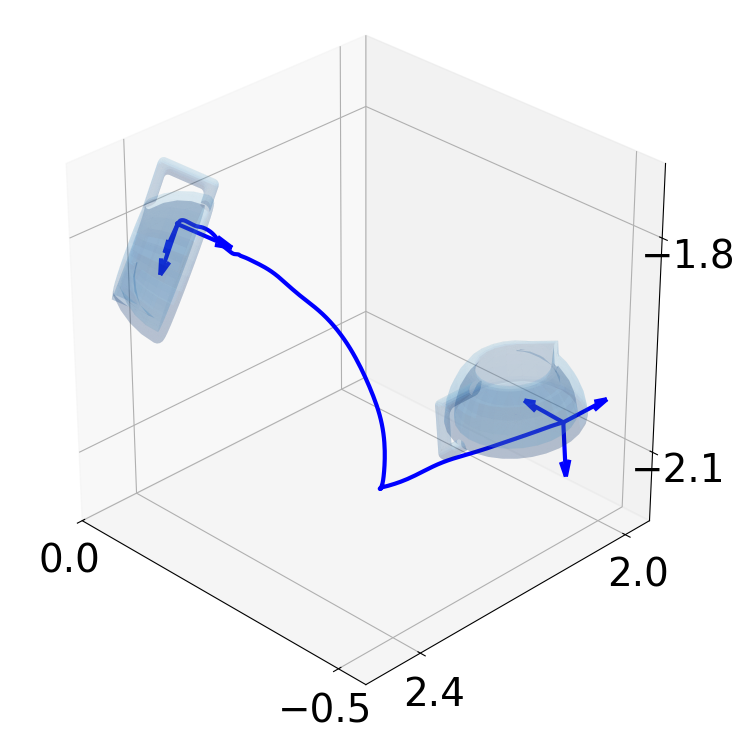

In [4]:
import matplotlib.pyplot as plt

import sulib._plotting as _plotting

# Load data of the rigid body for visualization
object_data = _dh.load_object_data(input_trajectory, path_to_data)

# Plot the trajectory
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")
key_values_body_frame, key_values_rigid_object = [0, -1], [0, -1]
ax = _plotting.plot_trajectory_origin(ax, T, color="b", linewidth=3.0)
ax = _plotting.plot_frames(ax, T, key_values_body_frame, color="b", linewidth=3.0, arrow_len=0.08)
ax = _plotting.plot_rigid_bodies(ax, T, key_values_rigid_object, object_data)
ax = _plotting.ax_settings_general(ax)
if input_trajectory == "pouring":
    ax = _plotting.ax_settings_pouring_trajectory(ax)
fig.savefig(rf"{path_to_figures}/input_trajectory.svg")

##### 4. Specify a value for the regularization parameter L (expressed in meters)

In [5]:
L = 0.3

##### 5. Calculate the DUTIR using the SU decomposition

In [6]:
import sulib

# Calculate dutir without regularization
dutir, _ = sulib.pose_trajectory_to_dutir(T, dt)

# Calculate dutir with regularization
dutir_reg, _ = sulib.pose_trajectory_to_dutir(T, dt, L)

##### 6. Visualize the computed DUTIR (red = unregularized, blue = regularized)

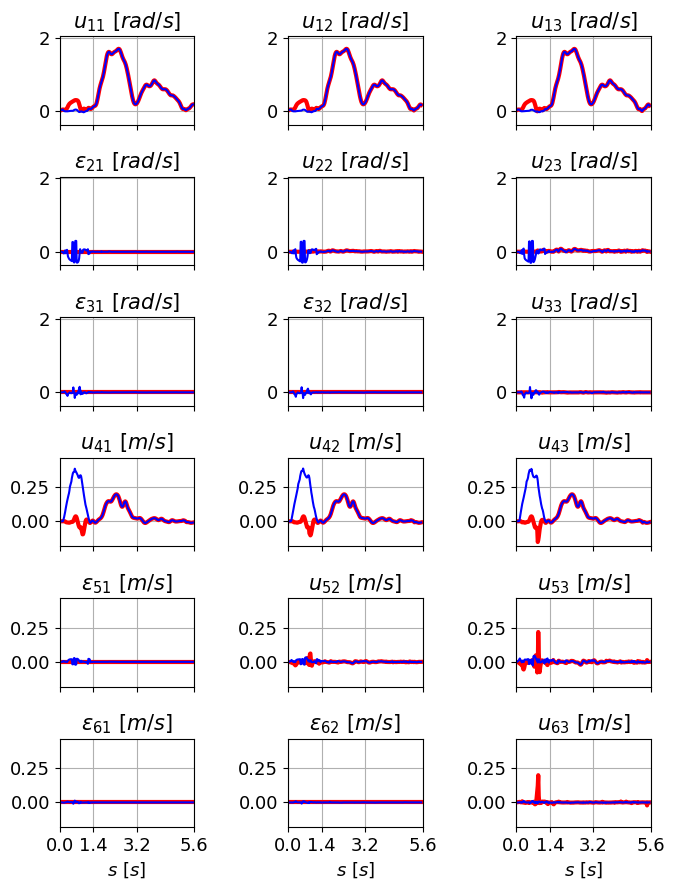

In [7]:
fig, axes = _plotting.initialize_plot_dutir("time", input_trajectory)
axes = _plotting.plot_dutir(axes, dutir, total_time, color="r", linewidth=3.0)
axes = _plotting.plot_dutir(axes, dutir_reg, total_time, color="b", linewidth=1.5)
axes = _plotting.ax_uniform_yaxis_limits_dutir(axes)
fig.savefig(rf"{path_to_figures}/dutir_notebook.svg")